In [51]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [52]:
print("Train shape:" , train.shape)
print("Test shape:" , test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [53]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [54]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [55]:
train['SalePrice'].describe()


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


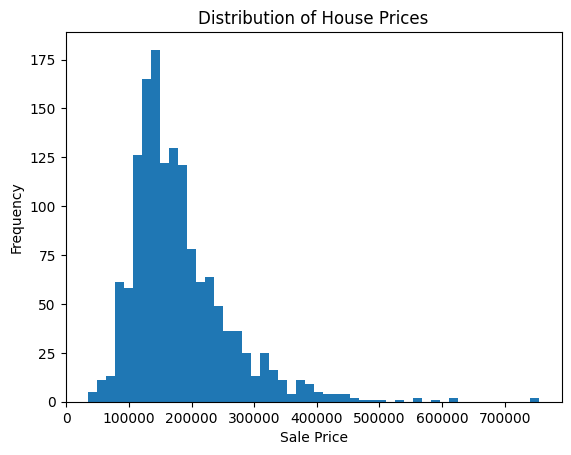

In [56]:
import matplotlib.pyplot as plt

plt.hist(train['SalePrice'], bins=50)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()


In [57]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.head(10)


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [58]:
missing_ratio = missing / len(train)

drop_cols = missing_ratio[missing_ratio > 0.4].index
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

print("Dropped columns:", list(drop_cols))


Dropped columns: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']


In [59]:
numeric_features = train.select_dtypes(include=['int64','float64']).columns
categorical_features = train.select_dtypes(include=['object']).columns

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 38
Categorical features: 37


In [60]:
import numpy as np

train['SalePrice'] = np.log1p(train['SalePrice'])


In [61]:
# Numerical features → median
for col in numeric_features:
    train[col] = train[col].fillna(train[col].median())
    if col in test.columns:
        test[col] = test[col].fillna(test[col].median())

# Categorical features → mode
for col in categorical_features:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])


In [62]:
train.isnull().sum().sum()


np.int64(0)

In [63]:
import numpy as np

train['SalePrice'] = np.log1p(train['SalePrice'])


In [64]:
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

train, test = train.align(test, join='left', axis=1)
test.fillna(0, inplace=True)


In [65]:
from sklearn.model_selection import train_test_split

X = train.drop('SalePrice', axis=1)
y = train['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

preds = lr.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
print("Linear Regression RMSE:", rmse)


Linear Regression RMSE: 0.01586721892318306


In [67]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_val)

rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
print("Random Forest RMSE:", rf_rmse)


Random Forest RMSE: 0.011620543451062813


In [68]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)
gbr_preds = gbr.predict(X_val)

gbr_rmse = np.sqrt(mean_squared_error(y_val, gbr_preds))
print("Gradient Boosting RMSE:", gbr_rmse)


Gradient Boosting RMSE: 0.011054869454223227


In [69]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [71]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)
gbr_preds = gbr.predict(X_val)

gbr_rmse = np.sqrt(mean_squared_error(y_val, gbr_preds))
print("Gradient Boosting RMSE:", gbr_rmse)


Gradient Boosting RMSE: 0.011054869454223227


In [72]:
models = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [lr_rmse, rf_rmse, gbr_rmse]
})

models


,Model,RMSE
0,Linear Regression,0.015867
1,Random Forest,0.011621
2,Gradient Boosting,0.011055


In [73]:
final_model = gbr
final_model.fit(X, y)


GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=300,
                          random_state=42)

In [74]:
if "SalePrice" in test.columns:
    test = test.drop("SalePrice", axis=1)


In [75]:
test = test[X.columns]


In [76]:
test_preds = final_model.predict(test)
test_preds = np.expm1(test_preds)  # reverse log transform


In [77]:
# Predict
test_preds = final_model.predict(test)

# Reverse log transform (VERY IMPORTANT)
test_preds = np.expm1(test_preds)


In [78]:
# Reload original test.csv ONLY to get Ids
raw_test = pd.read_csv("/content/test.csv")
test_ids = raw_test["Id"]


In [79]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_preds
})

submission.to_csv("submission.csv", index=False)


In [80]:
submission.head()


,Id,SalePrice
0,1461,11.669054
1,1462,11.886959
2,1463,12.108442
3,1464,12.133353
4,1465,12.074263


In [81]:
# Check full duplicate rows
train.duplicated().sum()


np.int64(0)

In [82]:
raw_train = pd.read_csv("/content/train.csv")


In [83]:
raw_train.duplicated(
    subset=["LotArea", "OverallQual", "GrLivArea", "Neighborhood"],
    keep=False
).sum()


np.int64(46)

In [84]:
raw_train = raw_train.drop_duplicates(
    subset=["LotArea", "OverallQual", "GrLivArea", "Neighborhood"],
    keep="first"
)


In [85]:
train["Id"].duplicated().sum()


np.int64(0)

In [86]:
print("Duplicates left:", train.duplicated().sum())
print("Shape after cleaning:", train.shape)


Duplicates left: 0
Shape after cleaning: (1460, 231)


In [87]:
train = train[train["GrLivArea"] < 4500]


In [88]:
submission = pd.DataFrame({
    "Id": test.index + 1,
    "SalePrice": test_preds
})

submission.to_csv("submission.csv", index=False)


In [90]:
raw_test = pd.read_csv("/content/test.csv")
raw_test["Id"].head(), raw_test["Id"].tail(), raw_test.shape


(0    1461
 1    1462
 2    1463
 3    1464
 4    1465
 Name: Id, dtype: int64,
 1454    2915
 1455    2916
 1456    2917
 1457    2918
 1458    2919
 Name: Id, dtype: int64,
 (1459, 80))

In [91]:
submission = pd.DataFrame({
    "Id": raw_test["Id"],
    "SalePrice": test_preds
})
submission.to_csv("submission.csv", index=False)


In [92]:
print(submission.shape)
print(submission["Id"].is_unique)
print(submission["Id"].min(), submission["Id"].max())


(1459, 2)
True
1461 2919
